## 1. Install Required Libraries

In [1]:
%pip install -q shap lime fairlearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 15.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 10.9 MB/s eta 0:00:00


## 2. Import Libraries

In [2]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import shap
from lime.lime_tabular import LimeTabularExplainer

from fairlearn.metrics import (
    MetricFrame,
    selection_rate,
    demographic_parity_difference,
    equalized_odds_difference
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

warnings.filterwarnings("ignore")
print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Upload the Cleaned Layoffs Dataset

In [3]:
from google.colab import files

print("Upload your cleaned Layoffs CSV file:")
uploaded = files.upload()

file_name = next(iter(uploaded.keys()))
df = pd.read_csv(file_name)

print("Selected file:", file_name)
print("Dataset shape:", df.shape)
display(df.head())

Upload your cleaned Layoffs CSV file:


Saving layoffs_cleaned _final.csv to layoffs_cleaned _final.csv
Selected file: layoffs_cleaned _final.csv
Dataset shape: (5676, 21)


,record_id,company,city,country,is_us,industry,stage,company_size_before,company_size_after,total_laid_off,...,funds_raised_mil,date,year,date_added,status,quarter,month_name,day_of_week,is_weekend,days_to_report
0,layoff_01916,Kaiyo,NEW YORK CITY,United States,True,Retail,Series B,397,633.0,54.0,...,43.0,2024-08-21,2024,2024-08-22,Unknown,3,August,Wednesday,False,1
1,layoff_00360,Trell,Bengaluru,India,False,Retail,Unknown,600,300.0,300.0,...,62.0,2022-03-15,2022,2022-05-07,Unknown,1,March,Tuesday,False,53
2,layoff_02462,Flowhub,Dever,unknown,False,Cannabis,Unknown,700,700.0,25.0,...,974.0,2022-09-09,2022,2022-09-09,Private,3,September,Friday,False,0
3,layoff_01425,trigo,Tel Aviv,Israel,False,Retail,Series C,200,170.0,30.0,...,199.0,2024-01-04,2024,2024-01-05,Unknown,1,January,Thursday,False,1
4,layoff_03829,New Relic,Unknown,United States,True,INFRASTRUCTURE,Post-IPO,2550,30.0,255.0,...,173.0,2023-06-27,2023,2023-06-27,Unknown,2,June,Tuesday,False,0


## 4. Create the Target Variable

In [4]:
if "percentage_laid_off" not in df.columns:
    raise ValueError("percentage_laid_off column is required.")

df["high_layoff"] = (df["percentage_laid_off"] >= 50).astype(int)

print("Target distribution:")
display(df["high_layoff"].value_counts())

Target distribution:


,count
high_layoff,
0,4887
1,789


## 5. Upload and Load the Best Model

In [5]:
print("Upload best_layoffs_model.pkl:")
uploaded_model = files.upload()

model_file = next(iter(uploaded_model.keys()))
best_model = joblib.load(model_file)

print("Model loaded successfully:")
print(best_model)

Upload best_layoffs_model.pkl:


Saving best_layoffs_model.pkl to best_layoffs_model.pkl
Model loaded successfully:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['company_size_before',
                                                   'company_size_after',
                                                   'total_laid_off',
                                                   'funds_raised_mil', 'year',
                                                   'quarter',
                                                   'days_to_report']),
                                                 ('cat

## 6. Prepare Features

In [6]:
target = "high_layoff"

excluded_columns = [
    "high_layoff",
    "percentage_laid_off",
    "company",
    "record_id",
    "date",
    "date_added"
]

feature_columns = [col for col in df.columns if col not in excluded_columns]

X = df[feature_columns].copy()
y = df[target].copy()

print("Features used:")
print(feature_columns)
print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features used:
['city', 'country', 'is_us', 'industry', 'stage', 'company_size_before', 'company_size_after', 'total_laid_off', 'funds_raised_mil', 'year', 'status', 'quarter', 'month_name', 'day_of_week', 'is_weekend', 'days_to_report']

X shape: (5676, 16)
y shape: (5676,)


## 7. Train/Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (4540, 16)
Testing set: (1136, 16)


## 8. Evaluate the Loaded Model

In [15]:
print("df shape:", df.shape)
print("X shape:", X.shape)
print("X_test shape:", X_test.shape)

print("\ndf columns:")
print(df.columns.tolist())

print("\nX columns:")
print(X.columns.tolist())

print(X.index[:10])
print(X_test.index[:10])

df shape: (5676, 22)
X shape: (5676, 16)
X_test shape: (1136, 16)

df columns:
['record_id', 'company', 'city', 'country', 'is_us', 'industry', 'stage', 'company_size_before', 'company_size_after', 'total_laid_off', 'percentage_laid_off', 'funds_raised_mil', 'date', 'year', 'date_added', 'status', 'quarter', 'month_name', 'day_of_week', 'is_weekend', 'days_to_report', 'high_layoff']

X columns:
['city', 'country', 'is_us', 'industry', 'stage', 'company_size_before', 'company_size_after', 'total_laid_off', 'funds_raised_mil', 'year', 'status', 'quarter', 'month_name', 'day_of_week', 'is_weekend', 'days_to_report']
RangeIndex(start=0, stop=10, step=1)
Index([2094, 1256, 4532, 3403, 5283, 1966, 3036, 13, 3923, 2470], dtype='int64')


In [16]:
X_test_fixed = X_test.copy()

X_test_fixed["record_id"] = df.iloc[X_test.index]["record_id"].values
X_test_fixed["date_added"] = df.iloc[X_test.index]["date_added"].values

In [17]:
expected_columns = best_model.named_steps["preprocessor"].feature_names_in_

X_test_fixed = X_test_fixed[expected_columns]

print("X_test_fixed shape:", X_test_fixed.shape)
print("Missing columns:",
      set(expected_columns) - set(X_test_fixed.columns))

X_test_fixed shape: (1136, 18)
Missing columns: set()


In [18]:
y_pred = best_model.predict(X_test_fixed)

print("Model:", type(best_model).__name__)
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Below 50%", "50% or More"],
        zero_division=0
    )
)

Model: Pipeline
Accuracy: 0.8697

Classification Report:
              precision    recall  f1-score   support

   Below 50%       0.87      0.99      0.93       978
 50% or More       0.71      0.11      0.19       158

    accuracy                           0.87      1136
   macro avg       0.79      0.55      0.56      1136
weighted avg       0.85      0.87      0.83      1136



## 9. SHAP — Create Prediction Function

In [25]:
def model_predict_proba(data):
    data_df = pd.DataFrame(data, columns=X_train.columns)
    return best_model.predict_proba(data_df)

print("SHAP prediction function created.")

SHAP prediction function created.


## 10. SHAP — Select Background and Explanation Samples

In [26]:
# Start with your current 16-feature test data
explanation_data = X_test.copy()

# Restore the two columns expected by the already-trained model
explanation_data["record_id"] = df.iloc[X_test.index]["record_id"].values
explanation_data["date_added"] = df.iloc[X_test.index]["date_added"].values

# Put columns in exactly the order expected by the model
expected_columns = best_model.named_steps["preprocessor"].feature_names_in_

explanation_data = explanation_data[expected_columns]

print("Explanation data shape:", explanation_data.shape)
print("Missing columns:", set(expected_columns) - set(explanation_data.columns))

Explanation data shape: (1136, 18)
Missing columns: set()


## 11. SHAP — Generate Explanations

In [28]:
background_data = explanation_data.sample(
    n=min(100, len(explanation_data)),
    random_state=42
)

In [29]:
preprocessor = best_model.named_steps["preprocessor"]
model = best_model.named_steps["model"]

background_transformed = preprocessor.transform(background_data)
explanation_transformed = preprocessor.transform(explanation_data)

print("Background shape:", background_transformed.shape)
print("Explanation shape:", explanation_transformed.shape)

Background shape: (100, 6680)
Explanation shape: (1136, 6680)


In [31]:
import shap

explainer = shap.Explainer(
    model.predict_proba,
    background_transformed
)

shap_values = explainer(explanation_transformed)

print("SHAP explanation generated successfully.")

PermutationExplainer explainer: 1137it [52:23,  2.77s/it]

SHAP explanation generated successfully.


## 12. SHAP — Global Feature Importance

In [34]:
values = shap_values.values

if values.ndim == 3:
    class1_values = values[:, :, 1]
else:
    class1_values = values

mean_abs_shap = np.abs(class1_values).mean(axis=0)

# Get names of the actual features used by SHAP
feature_names = preprocessor.get_feature_names_out()

print("SHAP features:", len(mean_abs_shap))
print("Feature names:", len(feature_names))

SHAP features: 6680
Feature names: 6680


In [35]:
shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": mean_abs_shap
}).sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

display(shap_importance)

,Feature,Mean_Absolute_SHAP
0,num__company_size_after,0.027331
1,num__funds_raised_mil,0.022471
2,cat__stage_Seed,0.016310
3,cat__stage_Post-IPO,0.012318
4,num__company_size_before,0.010586
...,...,...
6675,cat__record_id_layoff_02794,0.000000
6676,cat__record_id_layoff_02792,0.000000
6677,cat__record_id_layoff_02791,0.000000
6678,cat__record_id_layoff_02790,0.000000


## 13. SHAP — Global Feature Importance Plot

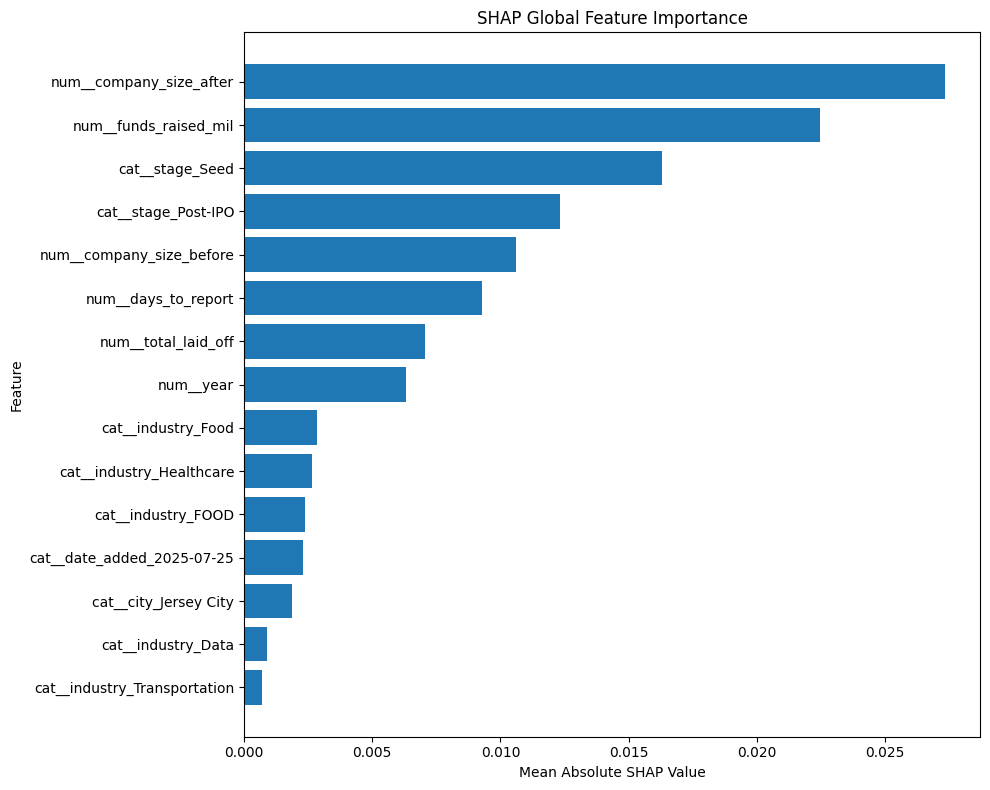

In [36]:
plt.figure(figsize=(10, 8))

top_features = shap_importance.head(15).sort_values(
    "Mean_Absolute_SHAP"
)

plt.barh(
    top_features["Feature"],
    top_features["Mean_Absolute_SHAP"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("SHAP Global Feature Importance")
plt.tight_layout()
plt.show()

## 14. SHAP — Summary / Beeswarm Plot

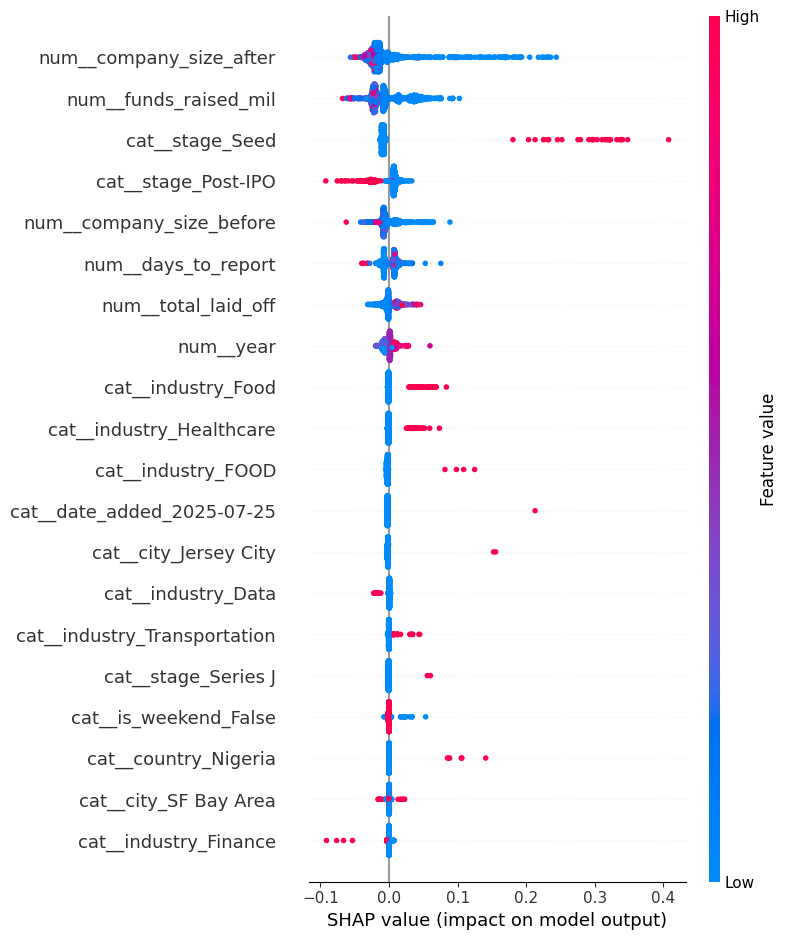

In [38]:
shap.summary_plot(
    class1_values,
    explanation_transformed,
    feature_names=feature_names,
    show=True
)

## 15. SHAP — Select Most Important Feature

In [39]:
top_feature = shap_importance.iloc[0]["Feature"]

print("Most important feature according to SHAP:")
print(top_feature)

Most important feature according to SHAP:
num__company_size_after


## 16. SHAP — Dependence Plot

Generating dependence plot for: num__company_size_after


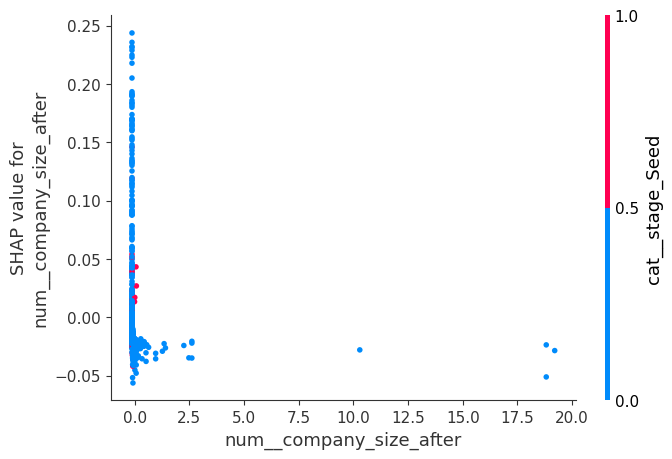

In [41]:
# Use the transformed data used to generate SHAP values
plot_data = explanation_transformed

# Feature names generated by the ColumnTransformer
feature_names = preprocessor.get_feature_names_out()

print("Generating dependence plot for:", top_feature)

shap.dependence_plot(
    top_feature,
    class1_values,
    plot_data,
    feature_names=feature_names,
    interaction_index="auto",
    show=True
)

## 17. LIME — Prepare Numerical Data

In [42]:
X_lime = X.copy()
category_mappings = {}

for col in X_lime.columns:
    if not pd.api.types.is_numeric_dtype(X_lime[col]):
        X_lime[col] = X_lime[col].astype("category")
        category_mappings[col] = X_lime[col].cat.categories
        X_lime[col] = X_lime[col].cat.codes

X_lime_train, X_lime_test, y_lime_train, y_lime_test = train_test_split(
    X_lime,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("LIME data prepared.")
print(X_lime_train.shape)

LIME data prepared.
(4540, 16)


## 18. LIME — Prediction Function

In [43]:
def lime_predict_proba(numpy_data):
    temp = pd.DataFrame(
        numpy_data,
        columns=X_lime_train.columns
    )

    for col, categories in category_mappings.items():
        temp[col] = temp[col].round().astype(int)
        temp[col] = temp[col].clip(0, len(categories) - 1)
        temp[col] = pd.Categorical.from_codes(
            temp[col],
            categories=categories
        )

    return best_model.predict_proba(temp)

## 19. LIME — Create Explainer

In [44]:
lime_explainer = LimeTabularExplainer(
    training_data=X_lime_train.values,
    feature_names=X_lime_train.columns.tolist(),
    class_names=["Below 50%", "50% or More"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

print("LIME explainer created successfully.")

LIME explainer created successfully.


## 20. LIME — Select Individual Prediction

In [46]:
sample_index = 0

# Get the sample from the current test set
original_sample = X_test.iloc[sample_index].copy()

# Add the two columns expected by the already-trained model
sample_for_model = X_test.iloc[[sample_index]].copy()

sample_for_model["record_id"] = df.iloc[
    X_test.index[sample_index]
]["record_id"]

sample_for_model["date_added"] = df.iloc[
    X_test.index[sample_index]
]["date_added"]

# Put columns in exactly the order expected by the trained model
expected_columns = best_model.named_steps["preprocessor"].feature_names_in_

sample_for_model = sample_for_model[expected_columns]

# Actual class
actual_class = y_test.iloc[sample_index]

# Prediction
prediction = best_model.predict(sample_for_model)[0]

# Prediction probabilities
prediction_probability = best_model.predict_proba(sample_for_model)[0]

print("Actual class:", actual_class)
print("Predicted class:", prediction)
print("Prediction probabilities:", prediction_probability)

display(original_sample.to_frame("Value"))

Actual class: 0
Predicted class: 0
Prediction probabilities: [0.69566394 0.30433606]


,Value
city,MANAMA
country,Bahrain
is_us,False
industry,Finance
stage,Series B
company_size_before,346
company_size_after,60.0
total_laid_off,95.0
funds_raised_mil,202.0
year,2022


## 21. LIME — Generate Local Explanation

In [48]:
# Columns expected by the already-trained model
expected_columns = best_model.named_steps["preprocessor"].feature_names_in_

# Create a copy of X_test with the missing columns restored
X_lime_input = X_test.copy()

X_lime_input["record_id"] = df.iloc[X_test.index]["record_id"].values
X_lime_input["date_added"] = df.iloc[X_test.index]["date_added"].values

# Match the exact order used during training
X_lime_input = X_lime_input[expected_columns]

print("LIME input shape:", X_lime_input.shape)
print("Missing:", set(expected_columns) - set(X_lime_input.columns))

LIME input shape: (1136, 18)
Missing: set()


In [49]:
sample_index = 0

sample = X_lime_input.iloc[sample_index].values
actual_class = y_test.iloc[sample_index]

In [50]:
def lime_predict_proba(x):
    x_df = pd.DataFrame(x, columns=expected_columns)
    return best_model.predict_proba(x_df)

In [54]:
import numpy as np
import pandas as pd
from lime.lime_tabular import LimeTabularExplainer

# Existing trained model
preprocessor = best_model.named_steps["preprocessor"]
model = best_model.named_steps["model"]

# Transform the data using the EXISTING fitted preprocessor
lime_background_transformed = preprocessor.transform(X_lime_input)

# Feature names after preprocessing / one-hot encoding
lime_feature_names = preprocessor.get_feature_names_out()

print("Transformed shape:", lime_background_transformed.shape)
print("Feature names:", len(lime_feature_names))

Transformed shape: (1136, 6680)
Feature names: 6680


In [55]:
lime_explainer = LimeTabularExplainer(
    lime_background_transformed,
    feature_names=list(lime_feature_names),
    class_names=["Below 50%", "50% or More"],
    mode="classification",
    random_state=42
)

In [56]:
def lime_predict_proba_transformed(x):
    return model.predict_proba(x)

In [57]:
sample_index = 0

sample = lime_background_transformed[sample_index]

actual_class = y_test.iloc[sample_index]

prediction_probability = model.predict_proba(
    sample.reshape(1, -1)
)[0]

prediction = np.argmax(prediction_probability)

print("Actual class:", actual_class)
print("Predicted class:", prediction)
print("Prediction probabilities:", prediction_probability)

Actual class: 0
Predicted class: 0
Prediction probabilities: [0.69566394 0.30433606]


In [58]:
lime_exp = lime_explainer.explain_instance(
    sample,
    lime_predict_proba_transformed,
    num_features=10
)

print("\nLIME explanation:")

for feature, contribution in lime_exp.as_list():
    print(f"{feature}: {contribution:.4f}")


LIME explanation:
cat__stage_Seed <= 0.00: -0.2839
cat__date_added_2023-12-10 <= 0.00: -0.1821
cat__country_Vietnam <= 0.00: -0.1821
cat__stage_SEED <= 0.00: -0.1628
cat__country_Nigeria <= 0.00: -0.1384
cat__date_added_2022-06-04 > 0.00: 0.1349
cat__date_added_2023-01-29 <= 0.00: -0.1275
cat__date_added_2026-01-23 <= 0.00: -0.1205
cat__country_Poland <= 0.00: -0.1097
cat__date_added_2022-08-12 <= 0.00: -0.1022


## 22. LIME — Visualization

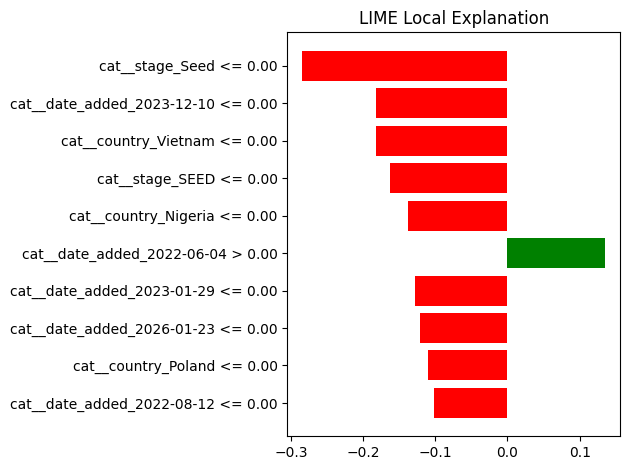

Saved: lime_local_explanation.html


In [59]:
fig = lime_exp.as_pyplot_figure()
plt.title("LIME Local Explanation")
plt.tight_layout()
plt.show()

lime_exp.save_to_file("lime_local_explanation.html")
print("Saved: lime_local_explanation.html")

## 23. Fairness Audit — Define Group Attribute

In [60]:
if "is_us" not in df.columns:
    raise ValueError("is_us column is not available in this dataset.")

sensitive_features = df.loc[
    X_test.index,
    "is_us"
].astype(str)

print("Group distribution:")
display(sensitive_features.value_counts())

Group distribution:


,count
is_us,
True,673
False,463


## 24. Fairlearn — Demographic Parity and Equalized Odds

In [61]:
dp_difference = demographic_parity_difference(
    y_test,
    y_pred,
    sensitive_features=sensitive_features
)

eo_difference = equalized_odds_difference(
    y_test,
    y_pred,
    sensitive_features=sensitive_features
)

print("Fairness Audit Results")
print("-" * 50)
print("Demographic Parity Difference:", round(dp_difference, 4))
print("Equalized Odds Difference:", round(eo_difference, 4))

Fairness Audit Results
--------------------------------------------------
Demographic Parity Difference: 0.0044
Equalized Odds Difference: 0.0348


## 25. Fairlearn — Group-wise Performance

In [62]:
metric_dict = {
    "Accuracy": accuracy_score,
    "Precision": lambda y_true, y_pred:
        precision_score(y_true, y_pred, zero_division=0),
    "Recall": lambda y_true, y_pred:
        recall_score(y_true, y_pred, zero_division=0),
    "F1 Score": lambda y_true, y_pred:
        f1_score(y_true, y_pred, zero_division=0),
    "Selection Rate": selection_rate
}

metric_frame = MetricFrame(
    metrics=metric_dict,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sensitive_features
)

print("Performance by group:")
display(metric_frame.by_group)

Performance by group:


,Accuracy,Precision,Recall,F1 Score,Selection Rate
is_us,,,,,
False,0.861771,0.818182,0.126761,0.219512,0.023758
True,0.875186,0.615385,0.091954,0.160000,0.019316


## 26. Fairness Visualization — Accuracy

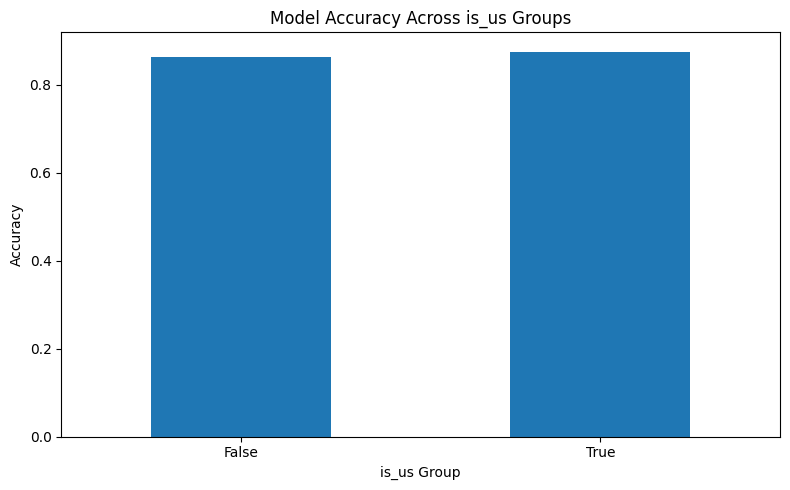

In [63]:
group_results = metric_frame.by_group.copy()

plt.figure(figsize=(8, 5))
group_results["Accuracy"].plot(kind="bar")
plt.title("Model Accuracy Across is_us Groups")
plt.xlabel("is_us Group")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 27. Fairness Visualization — Selection Rate

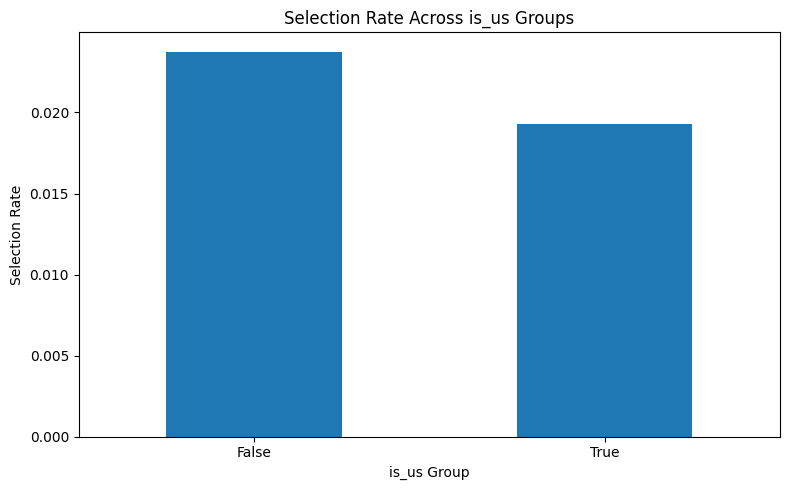

In [64]:
plt.figure(figsize=(8, 5))
group_results["Selection Rate"].plot(kind="bar")
plt.title("Selection Rate Across is_us Groups")
plt.xlabel("is_us Group")
plt.ylabel("Selection Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 28. Fairness Report

In [65]:
fairness_report = pd.DataFrame({
    "Metric": [
        "Demographic Parity Difference",
        "Equalized Odds Difference"
    ],
    "Value": [
        dp_difference,
        eo_difference
    ]
})

print("Overall fairness metrics:")
display(fairness_report)

print("\nGroup-wise performance:")
display(metric_frame.by_group)

Overall fairness metrics:


,Metric,Value
0,Demographic Parity Difference,0.004442
1,Equalized Odds Difference,0.034807



Group-wise performance:


,Accuracy,Precision,Recall,F1 Score,Selection Rate
is_us,,,,,
False,0.861771,0.818182,0.126761,0.219512,0.023758
True,0.875186,0.615385,0.091954,0.160000,0.019316


## 29. Fairness Interpretation

In [66]:
print("=" * 70)
print("FAIRNESS INTERPRETATION")
print("=" * 70)

print(f"\nDemographic Parity Difference: {dp_difference:.4f}")
print(f"Equalized Odds Difference: {eo_difference:.4f}")

if abs(dp_difference) < 0.10:
    print("\nDemographic parity: The difference in positive prediction rates is relatively small.")
else:
    print("\nDemographic parity: A noticeable difference exists between groups and further investigation is recommended.")

if abs(eo_difference) < 0.10:
    print("\nEqualized odds: The difference in error-related behavior is relatively small.")
else:
    print("\nEqualized odds: A noticeable difference exists between groups and further investigation is recommended.")

FAIRNESS INTERPRETATION

Demographic Parity Difference: 0.0044
Equalized Odds Difference: 0.0348

Demographic parity: The difference in positive prediction rates is relatively small.

Equalized odds: The difference in error-related behavior is relatively small.


## 30. Optional Bias Mitigation — Reweighting

In [67]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

group_counts = sensitive_features.value_counts()

group_weights = {
    group: len(sensitive_features) / count
    for group, count in group_counts.items()
}

sample_weights_test_indexed = sensitive_features.map(group_weights)

train_group_features = df.loc[X_train.index, "is_us"].astype(str)
train_sample_weights = train_group_features.map(group_weights).values

print("Group weights:")
print(group_weights)

Group weights:
{'True': 1.687964338781575, 'False': 2.4535637149028076}


## 31. Train Reweighted Random Forest

In [68]:

try:
    fair_rf = Pipeline([
        ("preprocessor", best_model.named_steps["preprocessor"]),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ])

    fair_rf.fit(
        X_train,
        y_train,
        model__sample_weight=train_sample_weights
    )

    fair_pred = fair_rf.predict(X_test)

    print("Reweighted model accuracy:",
          round(accuracy_score(y_test, fair_pred), 4))

except Exception as e:
    print("Optional mitigation model could not be trained.")
    print("Reason:", e)
    print("You can still report the proposed mitigation strategies.")

Optional mitigation model could not be trained.
Reason: A given column is not a column of the dataframe
You can still report the proposed mitigation strategies.


## 32. Compare Original and Mitigated Model

In [69]:
if "fair_pred" in globals():

    original_dp = demographic_parity_difference(
        y_test, y_pred,
        sensitive_features=sensitive_features
    )

    mitigated_dp = demographic_parity_difference(
        y_test, fair_pred,
        sensitive_features=sensitive_features
    )

    original_eo = equalized_odds_difference(
        y_test, y_pred,
        sensitive_features=sensitive_features
    )

    mitigated_eo = equalized_odds_difference(
        y_test, fair_pred,
        sensitive_features=sensitive_features
    )

    mitigation_comparison = pd.DataFrame({
        "Model": ["Original Model", "Reweighted Model"],
        "Accuracy": [
            accuracy_score(y_test, y_pred),
            accuracy_score(y_test, fair_pred)
        ],
        "Demographic Parity Difference": [
            original_dp,
            mitigated_dp
        ],
        "Equalized Odds Difference": [
            original_eo,
            mitigated_eo
        ]
    })

    display(mitigation_comparison)
else:
    print("Mitigation comparison skipped.")

Mitigation comparison skipped.


## 33. Save Experiment 5 Results

In [70]:
shap_importance.to_csv(
    "shap_feature_importance.csv",
    index=False
)

fairness_report.to_csv(
    "fairness_audit_report.csv",
    index=False
)

metric_frame.by_group.to_csv(
    "fairness_group_metrics.csv"
)

print("Experiment 5 result files saved:")
print("1. shap_feature_importance.csv")
print("2. fairness_audit_report.csv")
print("3. fairness_group_metrics.csv")
print("4. lime_local_explanation.html")

Experiment 5 result files saved:
1. shap_feature_importance.csv
2. fairness_audit_report.csv
3. fairness_group_metrics.csv
4. lime_local_explanation.html


## 34. Final Summary

In [71]:
print("=" * 75)
print("EXPERIMENT 5 — XAI & FAIRNESS ANALYSIS")
print("=" * 75)

print("\nModel:", type(best_model).__name__)

print("Model Accuracy:",
      round(accuracy_score(y_test, y_pred), 4))

print("Model Precision:",
      round(precision_score(y_test, y_pred, zero_division=0), 4))

print("Model Recall:",
      round(recall_score(y_test, y_pred, zero_division=0), 4))

print("Model F1:",
      round(f1_score(y_test, y_pred, zero_division=0), 4))

print("\nTop 10 SHAP Features:")
display(shap_importance.head(10))

print("Demographic Parity Difference:",
      round(dp_difference, 4))

print("Equalized Odds Difference:",
      round(eo_difference, 4))

print("\nExperiment 5 completed successfully.")

EXPERIMENT 5 — XAI & FAIRNESS ANALYSIS

Model: Pipeline
Model Accuracy: 0.8697
Model Precision: 0.7083
Model Recall: 0.1076
Model F1: 0.1868

Top 10 SHAP Features:


,Feature,Mean_Absolute_SHAP
0,num__company_size_after,0.027331
1,num__funds_raised_mil,0.022471
2,cat__stage_Seed,0.016310
3,cat__stage_Post-IPO,0.012318
4,num__company_size_before,0.010586
5,num__days_to_report,0.009295
6,num__total_laid_off,0.007074
7,num__year,0.006330
8,cat__industry_Food,0.002863
9,cat__industry_Healthcare,0.002654


Demographic Parity Difference: 0.0044
Equalized Odds Difference: 0.0348

Experiment 5 completed successfully.
